Размер выборки: 1000
Количество ячеек: 10^2 = 100
Ожидаемое число на ячейку (среднее): 5.00
Сумма ожидаемых частот: 500 (должна быть 500)
p-значение: 0.498126
Статистика хи-квадрат: 98.4000


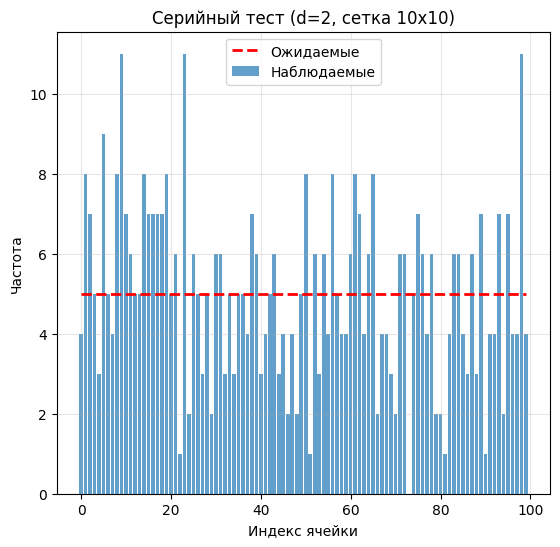

In [1]:
# Problem 1
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


np.random.seed(42)
samples = [np.random.random() for _ in range(1000)]

print(f"Размер выборки: {len(samples)}")

d = 2  # размерность серий
k = 10  # количество интервалов по каждому измерению

n = len(samples)
n_pairs = n // d
pairs = np.array(samples[:n_pairs * d]).reshape(n_pairs, d)


digitized = np.floor(pairs * k).astype(int)
digitized = np.clip(digitized, 0, k - 1)  # защита от значения 1.0


flat_indices = digitized[:, 0] * k + digitized[:, 1]

f_obs = np.histogram(flat_indices, bins=range(k**2 + 1))[0]

f_exp = np.full(k**2, n_pairs // (k**2))

remainder = n_pairs % (k**2)
if remainder > 0:
    f_exp[:remainder] += 1

print(f"Количество ячеек: {k}^{d} = {k**d}")
print(f"Ожидаемое число на ячейку (среднее): {n_pairs/(k**d):.2f}")
print(f"Сумма ожидаемых частот: {f_exp.sum()} (должна быть {n_pairs})")


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(range(k**2), f_obs, alpha=0.7, label='Наблюдаемые', width=0.8)
plt.plot(range(k**2), f_exp, 'r--', linewidth=2, label='Ожидаемые')
plt.xlabel('Индекс ячейки')
plt.ylabel('Частота')
plt.title(f'Серийный тест (d={d}, сетка {k}x{k})')
plt.legend()
plt.grid(True, alpha=0.3)

chi2_stat, p_value = stats.chisquare(f_obs, f_exp)
print(f"p-значение: {p_value:.6f}")
print(f"Статистика хи-квадрат: {chi2_stat:.4f}")



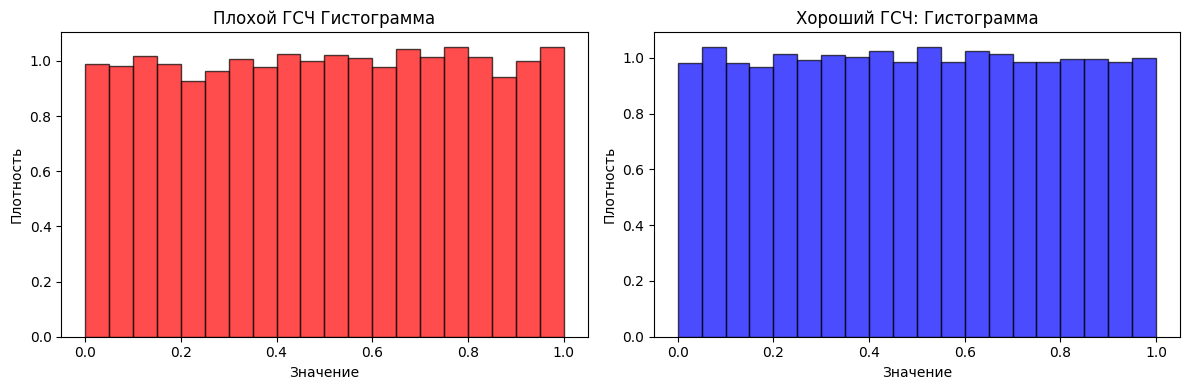


Тест Колмогорова-Смирнова на равномерность:
   RANDU:  p-value = 0.027778
   GOOD:   p-value = 0.854552


In [ ]:
# Problem 3
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def rng_bad(m=2**31, a=65539, c=0):
    """Плохой генератор"""
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

def rng_good():
    """Хороший генератор (numpy)"""
    return np.random.random()


np.random.seed(42)
n_samples = 30000

bad_random = [rng_bad() for _ in range(n_samples)]
good_random = [rng_good() for _ in range(n_samples)]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(bad_random, bins=20, density=True, alpha=0.7, color='red', edgecolor='black')
plt.title('Плохой ГСЧ Гистограмма')
plt.xlabel('Значение')
plt.ylabel('Плотность')

plt.subplot(1, 2, 2)
plt.hist(good_random, bins=20, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title('Хороший ГСЧ: Гистограмма')
plt.xlabel('Значение')
plt.ylabel('Плотность')

plt.tight_layout()
plt.show()

ks_bad = stats.kstest(bad_random, 'uniform')
ks_good = stats.kstest(good_random, 'uniform')

print("\nТест Колмогорова-Смирнова на равномерность:")
print(f"   RANDU:  p-value = {ks_bad.pvalue:.6f}")
print(f"   GOOD:   p-value = {ks_good.pvalue:.6f}")


Цифры:     [0 1 2 3 4 5 6 7 8 9]
Веса:      ['0.120', '0.300', '0.167', '0.240', '0.310', '0.540', '0.111', '0.020', '0.001', '0.200']
Сумма весов: 2.009

Упорядоченные веса (по убыванию):
  Цифра 5: вес = 0.2688
  Цифра 4: вес = 0.1543
  Цифра 1: вес = 0.1493
  Цифра 3: вес = 0.1195
  Цифра 9: вес = 0.0996
  Цифра 2: вес = 0.0831
  Цифра 0: вес = 0.0597
  Цифра 6: вес = 0.0553
  Цифра 7: вес = 0.0100
  Цифра 8: вес = 0.0005
Простой метод:        0.000094 сек
Оптимизированный:     0.000143 сек


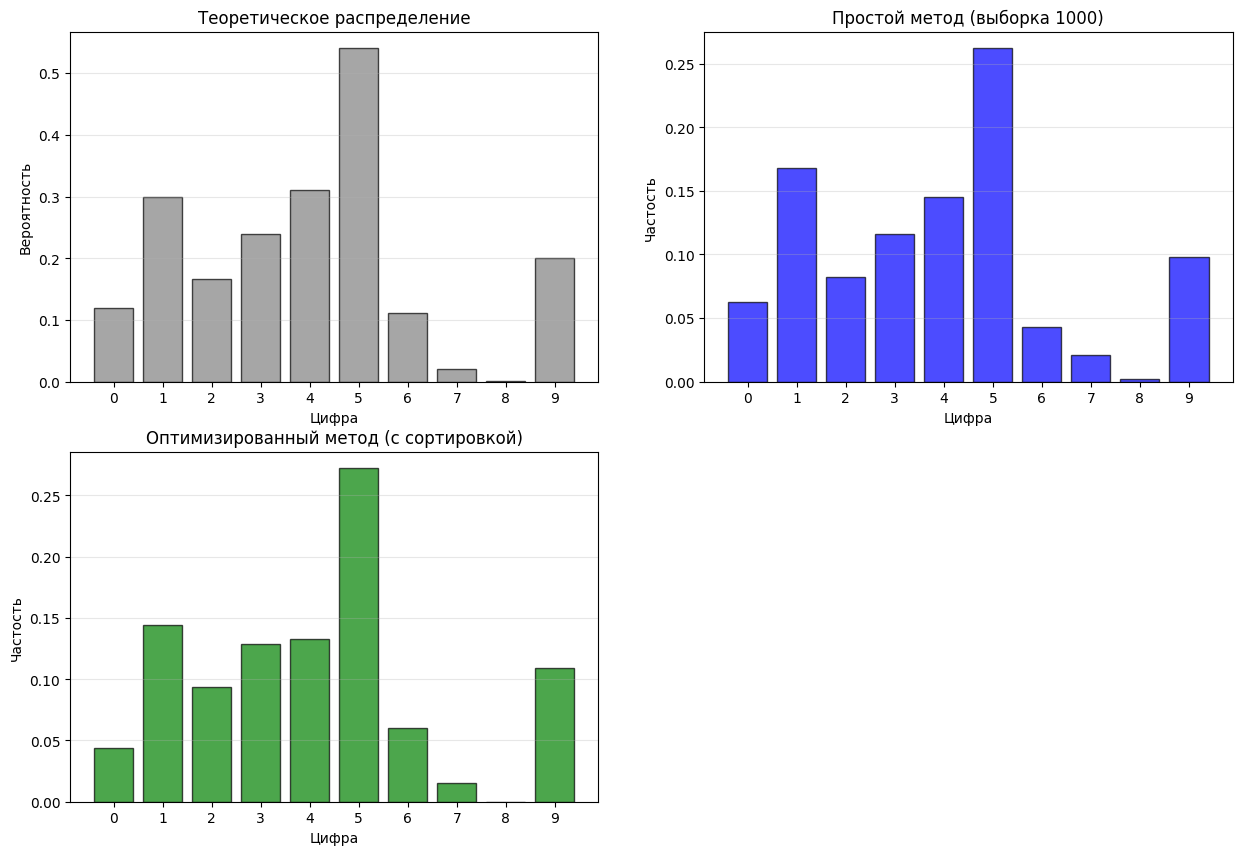

In [ ]:
# Problem 4
import numpy as np
import matplotlib.pyplot as plt
import time


digits = np.arange(10) 
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

print(f"Цифры:     {digits}")
print(f"Веса:      {[f'{w:.3f}' for w in weights]}")
print(f"Сумма весов: {np.sum(weights):.3f}")


def sample_discrete_simple(digits, weights, n_samples):
    
    weights = weights / np.sum(weights)
    cum_probs = np.cumsum(weights)
    u = np.random.random(n_samples)
    indices = np.searchsorted(cum_probs, u)
    return digits[indices]


def sample_discrete_optimized(digits, weights, n_samples):
    """
    Оптимизированный метод: сортируем веса по убыванию,
    чтобы чаще встречающиеся значения проверялись первыми
    """
    weights = weights / np.sum(weights)
    
    sorted_indices = np.argsort(weights)[::-1]
    sorted_digits = digits[sorted_indices]
    sorted_weights = weights[sorted_indices]
    
    print(f"\nУпорядоченные веса (по убыванию):")
    for i in range(10):
        print(f"  Цифра {sorted_digits[i]}: вес = {sorted_weights[i]:.4f}")
    
    
    cum_probs = np.cumsum(sorted_weights)
    
    
    u = np.random.random(n_samples)
    indices = np.searchsorted(cum_probs, u)
    
    return sorted_digits[indices]

np.random.seed(42)
n_samples = 1000

start = time.time()
sample_simple = sample_discrete_simple(digits, weights, n_samples)
time_simple = time.time() - start

start = time.time()
sample_optimized = sample_discrete_optimized(digits, weights, n_samples)
time_optimized = time.time() - start

print(f"Простой метод:        {time_simple:.6f} сек")
print(f"Оптимизированный:     {time_optimized:.6f} сек")


plt.figure(figsize=(15, 10))

# Теоретические вероятности
plt.subplot(2, 2, 1)
plt.bar(digits, weights, alpha=0.7, color='gray', edgecolor='black')
plt.title('Теоретическое распределение')
plt.xlabel('Цифра')
plt.ylabel('Вероятность')
plt.xticks(digits)
plt.grid(axis='y', alpha=0.3)

# Гистограмма для простого метода
plt.subplot(2, 2, 2)
counts_simple = np.bincount(sample_simple, minlength=10)
plt.bar(digits, counts_simple/n_samples, alpha=0.7, color='blue', edgecolor='black')
plt.title(f'Простой метод (выборка {n_samples})')
plt.xlabel('Цифра')
plt.ylabel('Частость')
plt.xticks(digits)
plt.grid(axis='y', alpha=0.3)

# Гистограмма для оптимизированного метода
plt.subplot(2, 2, 3)
counts_optimized = np.bincount(sample_optimized, minlength=10)
plt.bar(digits, counts_optimized/n_samples, alpha=0.7, color='green', edgecolor='black')
plt.title(f'Оптимизированный метод (с сортировкой)')
plt.xlabel('Цифра')
plt.ylabel('Частость')
plt.xticks(digits)
plt.grid(axis='y', alpha=0.3)

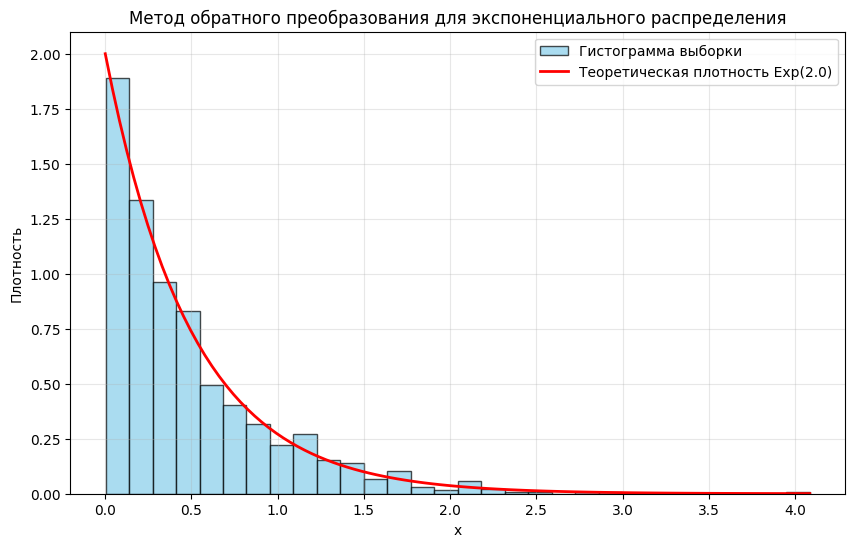

In [4]:
# Problem 5
import numpy as np
import matplotlib.pyplot as plt

lam = 2.0

# Метод обратного преобразования для экспоненциального распределения
# F(x) = 1 - exp(-λx)  =>  F^{-1}(u) = -ln(1-u)/λ
np.random.seed(42)
n = 1000
u = np.random.rand(n)
sample = -np.log(1 - u) / lam

x = np.linspace(0, max(sample), 100)
density = lam * np.exp(-lam * x)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=30, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='Гистограмма выборки')
plt.plot(x, density, 'r-', linewidth=2, label=f'Теоретическая плотность Exp({lam})')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Метод обратного преобразования для экспоненциального распределения')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

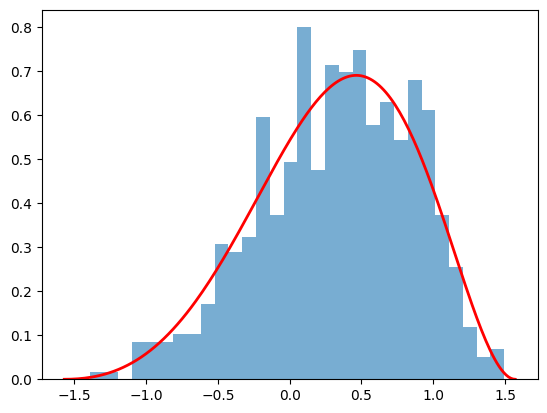

In [ ]:
# Problem 6
import numpy as np
import matplotlib.pyplot as plt

a, b = -np.pi/2, np.pi/2
M = np.exp(np.pi/2)

def target(x): return np.exp(x) * np.cos(x)**2

np.random.seed(42)
n = 1000

x_prop = np.random.uniform(a, b, 5*n)
y_prop = np.random.uniform(0, M, 5*n)
samples = x_prop[y_prop < target(x_prop)][:n]

x = np.linspace(a, b, 200)
target_norm = target(x) / np.trapezoid(target(x), x)

plt.hist(samples, bins=30, density=True, alpha=0.6)
plt.plot(x, target_norm, 'r-', linewidth=2)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16412\2702627987.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon = Polygon(vertices, closed=True, alpha=0.3, color='lightblue', edgecolor='blue')


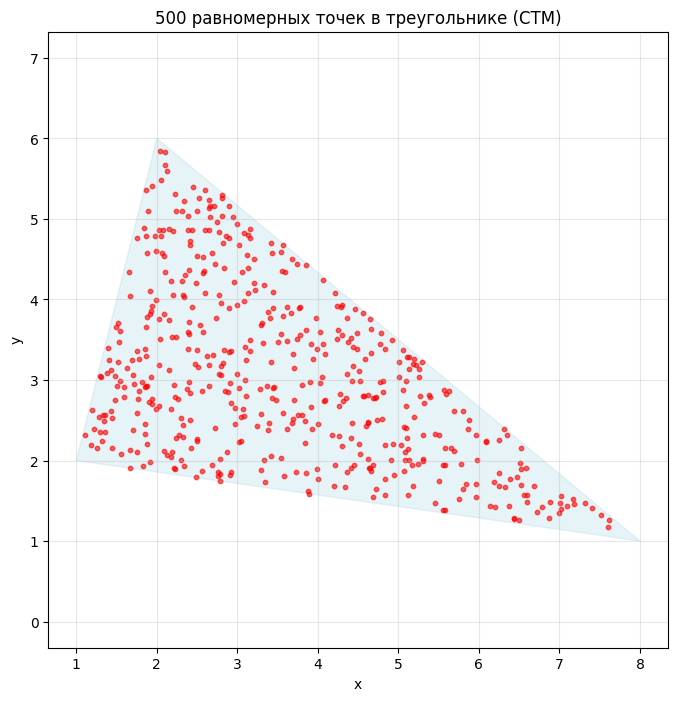

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

vertices = np.array([[1, 2], [2, 6], [8, 1]])

# Используем координаты: 
# Точка = v0 + (v1 - v0) * sqrt(u1) * (1 - u2) + (v2 - v0) * sqrt(u1) * u2

np.random.seed(42)
n_points = 500

u1 = np.random.rand(n_points)
u2 = np.random.rand(n_points)


sqrt_u1 = np.sqrt(u1)
points = np.zeros((n_points, 2))

for i in range(n_points):
    points[i] = (vertices[0] + 
                 (vertices[1] - vertices[0]) * sqrt_u1[i] * (1 - u2[i]) +
                 (vertices[2] - vertices[0]) * sqrt_u1[i] * u2[i])

fig, ax = plt.subplots(figsize=(8, 8))


polygon = Polygon(vertices, closed=True, alpha=0.3, color='lightblue', edgecolor='blue')
ax.add_patch(polygon)

ax.scatter(points[:, 0], points[:, 1], s=10, alpha=0.6, color='red')

ax.set_title('500 равномерных точек в треугольнике (CTM)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.axis('equal')
ax.grid(alpha=0.3)

plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


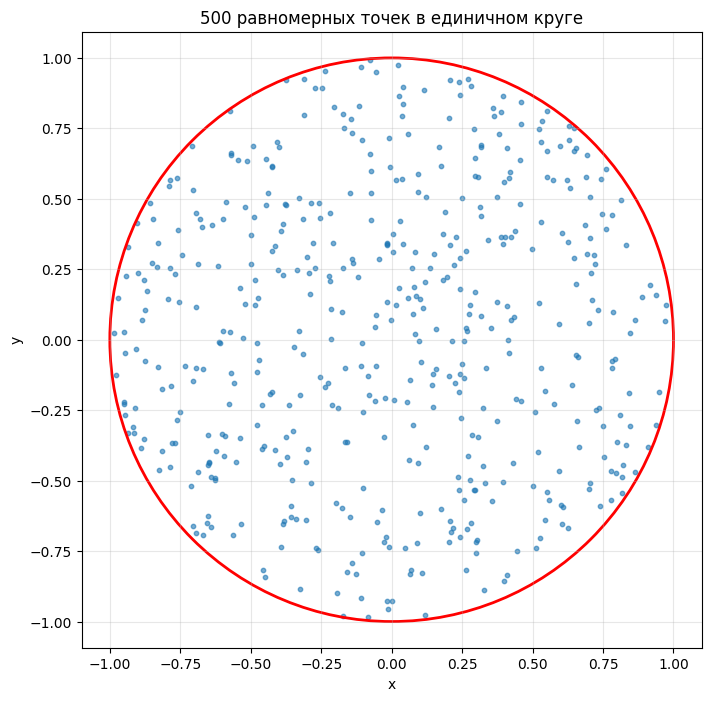

Среднее расстояние от центра: 0.6618 (теоретическое: 2/3 ≈ 0.6667)
Доля точек внутри круга: 1.0 (все внутри по построению)


In [10]:
# Problem 8
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

r = np.sqrt(np.random.rand(n))
theta = 2 * np.pi * np.random.rand(n)

x = r * np.cos(theta)
y = r * np.sin(theta)


plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=10, alpha=0.6)
plt.gca().add_patch(plt.Circle((0, 0), 1, fill=False, edgecolor='red', linewidth=2))
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title('500 равномерных точек в единичном круге')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

print(f"Среднее расстояние от центра: {np.mean(r):.4f} (теоретическое: 2/3 ≈ 0.6667)")
print(f"Доля точек внутри круга: 1.0 (все внутри по построению)")

Точное среднее (μ):        [4 7]
Выборочное среднее:        [4.25483191 7.15681175]

Точная ковариация (Σ):
[[20 -4]
 [-4 40]]

Выборочная ковариация:
[[20.60284698 -4.04995056]
 [-4.04995056 37.04336151]]


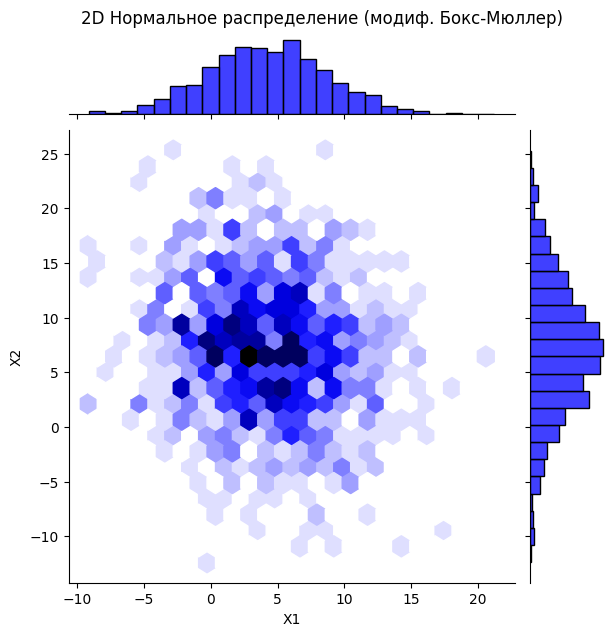

In [14]:
# Problem 9
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])


def box_muller_polar(n):
    """Генерирует n пар стандартных нормальных чисел, используя полярную форму."""
    z = np.zeros((n, 2))
    i = 0
    while i < n:
        u = 2 * np.random.rand(2) - 1
        s = u[0]**2 + u[1]**2
        if 0 < s < 1:
            factor = np.sqrt(-2 * np.log(s) / s)
            z[i] = u * factor
            i += 1
    return z

np.random.seed(42)
n_samples = 1000

z = box_muller_polar(n_samples)

L = np.linalg.cholesky(Sigma)
x = mu + z @ L.T 

sample_mean = np.mean(x, axis=0)
sample_cov = np.cov(x.T)

print(f"Точное среднее (μ):        {mu}")
print(f"Выборочное среднее:        {sample_mean}")
print(f"\nТочная ковариация (Σ):\n{Sigma}")
print(f"\nВыборочная ковариация:\n{sample_cov}")

# 5. Визуализация
joint_plot = sns.jointplot(x=x[:, 0], y=x[:, 1], kind='hex', color='blue')
joint_plot.set_axis_labels('X1', 'X2')
plt.suptitle('2D Нормальное распределение (модиф. Бокс-Мюллер)', y=1.02)
plt.show()